In [104]:
import sys
sys.path.append('../../')
import numpy as np
import open3d as o3d
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import os
import trimesh as tm
import scipy.sparse as sp
from scipy.sparse import csr_matrix, eye 
from scipy.sparse.linalg import eigs, spsolve, eigsh
from scipy.linalg import eigh
from collections import defaultdict

# output folder
out_dir = "mesh_exports"
os.makedirs(out_dir, exist_ok=True)

# Task 1

In [5]:
def first_form(u, v):

    p_u = np.array([np.cos(v), np.sin(v), 0]) 
    p_v = np.array([-u*np.sin(v), u*np.cos(v), 1]) 

    I = np.array([[p_u @ p_u, p_u @ p_v],
                  [p_u @ p_v, p_v @ p_v]])
    
    return p_u, p_v, I

def second_form(u, v):

    p_uu = np.array([0, 0, 0], dtype=float) 
    p_uv = np.array([-np.sin(v), np.cos(v), 0]) 
    p_vv = np.array([-u*np.cos(v), -u*np.sin(v), 0])

    p_u, p_v, _ = first_form(u, v)
    normal = np.cross(p_u, p_v)
    normal /= np.linalg.norm(normal)

    II = np.array([[p_uu @ normal, p_uv @ normal],
                   [p_uv @ normal, p_vv @ normal]])
    
    return p_uu, p_uv, p_vv, II

def normal_curvature(t_bar):

    # p(0, 0) = (0, 0, 0)
    u, v = 0, 0

    _, _, I  = first_form(u, v)
    _, _, _, II = second_form(u, v)
    
    k_n = (t_bar @ II @ t_bar) / (t_bar @ I @ t_bar)
    
    return k_n

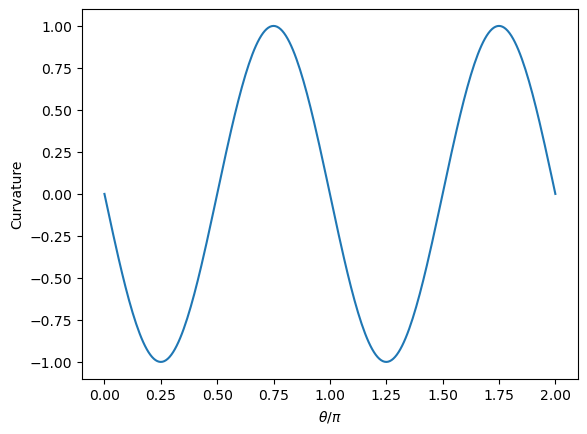

In [6]:
angle_values = np.linspace(0, 2 * np.pi, 2**8 + 1)

curvature_values = [normal_curvature(np.array([np.cos(angle), np.sin(angle)]).T) for angle in angle_values]

plt.ylabel('Curvature')
plt.xlabel('$\\theta / \pi$')
plt.plot(angle_values / np.pi, curvature_values)
plt.show()

# Task 2

In [8]:
def ordered_one_ring(mesh, vertex_idx):
    
    # find all faces that include the vertex
    faces = mesh.faces
    vertex_faces = [face for face in faces if vertex_idx in face] 
    
    # build a mapping of each neighbour to the next in the ring
    neighbours = defaultdict(list)
    for face in vertex_faces:
        ring = [vertex for vertex in face if vertex != vertex_idx] 
        a, b = ring[0], ring[1]
        # add the edge (a, b) to the mapping
        neighbours[a].append(b)
        neighbours[b].append(a)

    # walk the ring until we return to the start or reach a dead end
    start = next(iter(neighbours)) 
    ordered = [start]
    previous = None
    current = start
    while True:
        next_neighbour = next((n for n in neighbours[current] if n != previous), None)
        if next_neighbour is None or next_neighbour == start:
            break

        ordered.append(next_neighbour)
        previous, current = current, next_neighbour

    return ordered

In [9]:
armadillo = tm.load('meshes_CW2/armadillo.obj')

# test on vertex 0
ring = ordered_one_ring(armadillo, 0)
print(f"One-ring of vertex 0: {ring}")
print(f"Number of neighbours: {len(ring)}")

One-ring of vertex 0: [702, 44191, 6782, 11679, 11658]
Number of neighbours: 5


# Task 3

In [13]:
def mean_curvature(mesh):

    vertices = mesh.vertices
    n = len(vertices) 
    H = np.zeros(n) 
    
    for i in range(n):
        # get the one-ring neighbours of vertex i
        ring = ordered_one_ring(mesh, i)
        if len(ring) == 0:
            continue

        # this is ∆x = (1/N) * sum(x_j - x_i) 
        laplacian = np.mean(vertices[ring], axis=0) - vertices[i]

        normal = mesh.vertex_normals[i]

        # H = -0.5 * dot(laplacian, normal)
        H[i] = -0.5 * np.dot(laplacian, normal)

    return H

In [11]:
# function for visualising curvature values on the mesh   

def visualise_curvature(mesh, values, title):
       
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(mesh.vertices)
    o3d_mesh.triangles = o3d.utility.Vector3iVector(mesh.faces)

    v = values.copy()
    v = np.clip(v, np.percentile(v, 5), np.percentile(v, 95)) # clip to remove outliers
    
    # avoid division by zero when normalizing if all values are the same (flat plane)
    if v.max() - v.min() > 1e-10: 
        v = (v - v.min()) / (v.max() - v.min())
    else:
        v = np.zeros_like(v)  # all same value, just show uniform colour

    # color code the mesh vertices
    colours = plt.cm.jet(v)[:, :3] #  goes from blue (low) to green to red (high)
    o3d_mesh.vertex_colors = o3d.utility.Vector3dVector(colours)
    o3d_mesh.compute_vertex_normals()

    o3d.visualization.draw_geometries([o3d_mesh], window_name=title)

In [93]:
lilium_s = tm.load('meshes_CW2/lilium_s.obj')
H = mean_curvature(lilium_s)
visualise_curvature(lilium_s, H, 'Mean Curvature H')

In [ ]:
def vertex_area(mesh):
    
    A = np.zeros(len(mesh.vertices))
    for face_idx, face in enumerate(mesh.faces):
        for vertex_idx in face:
            A[vertex_idx] += mesh.area_faces[face_idx] / 3 
            
    return A

def gauss_curvature(mesh):
    
    thetas = np.zeros(len(mesh.vertices))
    for face, angles in zip(mesh.faces, mesh.face_angles):
        thetas[face] += angles

    A = vertex_area(mesh)
    K = np.zeros(len(mesh.vertices))

    # detect boundary vertices
    boundary = tm.grouping.group_rows(mesh.edges_sorted, require_count=1)
    boundary_verts = np.unique(mesh.edges_sorted[boundary])

    for i in range(len(K)):
        if i in boundary_verts:
            K[i] = (np.pi - thetas[i]) / A[i]   # boundary fix
        else:
            K[i] = (2 * np.pi - thetas[i]) / A[i]

    return K

In [76]:
K = gauss_curvature(lilium_s)
visualise_curvature(lilium_s, K, 'Gaussian Curvature K')

# Task 4

In [ ]:
def cotangent_weights(mesh):

    vertices = mesh.vertices
    faces = mesh.faces
    n = len(vertices)

    W = np.zeros((n, n))

    for face in faces:
        i, j, k = face

        for vi, vj, vk in [(i, j, k), (j, k, i), (k, i, j)]:
            # angle at vk, opposite edge (vi, vj)
            e1 = vertices[vi] - vertices[vk]
            e2 = vertices[vj] - vertices[vk]

            cos_a = np.dot(e1, e2)
            sin_a = np.linalg.norm(np.cross(e1, e2))

            cot_a = cos_a / sin_a if sin_a > 1e-8 else 0.0

            W[vi, vj] += cot_a
            W[vj, vi] += cot_a

    return W


def boundary_vertices(mesh):
    boundary = tm.grouping.group_rows(mesh.edges_sorted, require_count=1)
    return np.unique(mesh.edges_sorted[boundary])


def mean_curvature_cot(mesh):

    vertices = mesh.vertices
    normals = mesh.vertex_normals
    n = len(vertices)

    W = cotangent_weights(mesh)
    A = vertex_area(mesh)

    H = np.zeros(n)

    for i in range(n):
        neighbours = mesh.vertex_neighbors[i]
        if len(neighbours) == 0 or A[i] < 1e-8:
            continue
        
        laplacian = np.sum( [W[i, j] * (vertices[j] - vertices[i]) for j in neighbours],axis=0)

        laplacian /= (2.0 * A[i])
        
        H[i] = -0.5 * np.dot(laplacian, normals[i])

    boundary_verts = boundary_vertices(mesh)
    H[boundary_verts] = 0.0

    return H

In [94]:
lilium_s = tm.load("meshes_CW2/lilium_s.obj")
plane = tm.load("meshes_CW2/plane.obj")

# unsigned mean curvature magnitude
H_lilium = mean_curvature_cot(lilium_s)
H_plane = mean_curvature_cot(plane)

visualise_curvature(lilium_s, H_lilium, 'Mean Curvature - Lilium_s.obj')
visualise_curvature(plane, H_plane, 'Mean Curvature - Plane.obj')

# Task 5

In [ ]:
def build_face_lookup(mesh):
    lookup = {}
    for face in mesh.faces:
        for v in face:
            if v not in lookup:
                lookup[v] = []
            lookup[v].append(face)
    return lookup

def neighbor_neighbor_fast(a, b, lookup):
    faces_a = set(map(tuple, lookup[a]))
    faces_b = set(map(tuple, lookup[b]))
    shared = faces_a & faces_b
    neighbors = []
    for face in shared:
        for v in face:
            if v != a and v != b:
                neighbors.append(v)
    unique = list(set(neighbors))
    if len(unique) == 2:
        return unique[0], unique[1]
    elif len(unique) == 1:
        return unique[0], None
    else:
        return None, None

def cotangent_laplace_beltrami(mesh):

    n_vertices = len(mesh.vertices)
    row_indices = []
    col_indices = []
    data = []
    A = vertex_area(mesh)
    lookup = build_face_lookup(mesh) 

    for i, neighbors in enumerate(mesh.vertex_neighbors):
        sum_cot = 0
        for neighbor in neighbors:
            n_f, n_b = neighbor_neighbor_fast(i, neighbor, lookup)

            vi_nf = mesh.vertices[i] - mesh.vertices[n_f]
            vj_nf = mesh.vertices[neighbor] - mesh.vertices[n_f]
            cos_alpha = np.dot(vi_nf, vj_nf) / (np.linalg.norm(vi_nf) * np.linalg.norm(vj_nf))
            cot_alpha = 1 / np.tan(np.arccos(np.clip(cos_alpha, -1, 1)))

            if n_b is not None:
                vi_nb = mesh.vertices[i] - mesh.vertices[n_b]
                vj_nb = mesh.vertices[neighbor] - mesh.vertices[n_b]
                cos_beta = np.dot(vi_nb, vj_nb) / (np.linalg.norm(vi_nb) * np.linalg.norm(vj_nb))
                cot_beta = 1 / np.tan(np.arccos(np.clip(cos_beta, -1, 1)))
            else:
                cot_beta = 0

            cot_weight = cot_alpha + cot_beta
            if cot_weight > 0:
                area_sum = A[i] + A[neighbor]
                cot_weight /= area_sum
                row_indices.append(i)
                col_indices.append(neighbor)
                data.append(cot_weight)
                sum_cot += cot_weight

        row_indices.append(i)
        col_indices.append(i)
        data.append(-sum_cot)

    L = csr_matrix((data, (row_indices, col_indices)), shape=(n_vertices, n_vertices))
    return L

In [126]:
def mesh_reconstruction(mesh, k):
    L = cotangent_laplace_beltrami(mesh)

    _, e = eigs(L, k=k, which='SM')
    e = e.real

    vertices = mesh.vertices
    smooth_vertices = np.zeros_like(vertices)

    for channel in range(3):
        coeffs = vertices[:, channel] @ e
        smooth_vertices[:, channel] = e @ coeffs

    smooth_mesh = mesh.copy()
    smooth_mesh.vertices = smooth_vertices

    return smooth_mesh

In [ ]:
armadillo = tm.load('meshes_CW2/armadillo.obj')

for k in [5, 15, 100]:
    reconstructed = mesh_reconstruction(armadillo, k)

    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(reconstructed.vertices)
    o3d_mesh.triangles = o3d.utility.Vector3iVector(reconstructed.faces)
    o3d.io.write_triangle_mesh(f'{out_dir}/armadillo_k{k}.obj', o3d_mesh)

# Task 6

In [156]:
def uniform_laplace_beltrami(mesh):
    
    n_vertices = len(mesh.vertices)
    row_indices = []
    col_indices = []
    data = []

    for i, neighbors in enumerate(mesh.vertex_neighbors):
        n_neighbors = len(neighbors)
        if n_neighbors > 0:
            weight = 1.0 / n_neighbors

            for neighbor in neighbors:
                row_indices.append(i)
                col_indices.append(neighbor)
                data.append(weight)

            row_indices.append(i)
            col_indices.append(i)
            data.append(-1.0)

    L = csr_matrix((data, (row_indices, col_indices)), shape=(n_vertices, n_vertices))
    return L

def explicit_mesh_smoothing(mesh, lam, max_iter=10):
    
    smoothed_mesh = mesh.copy()
    for _ in range(max_iter):
        L = uniform_laplace_beltrami(smoothed_mesh)
        smoothed_mesh.vertices += lam * L @ smoothed_mesh.vertices
        
    return smoothed_mesh

In [ ]:
for fname in ['cube.obj', 'smoothing/fandisk_ns.obj']:
    mesh = tm.load(f'meshes_CW2/{fname}')

    for lam, iters in [(0.01, 10), (0.1, 10), (0.5, 10)]:
        smoothed = explicit_mesh_smoothing(mesh, lam, iters)

        o3d_mesh = o3d.geometry.TriangleMesh()
        o3d_mesh.vertices = o3d.utility.Vector3dVector(smoothed.vertices)
        o3d_mesh.triangles = o3d.utility.Vector3iVector(smoothed.faces)
        o3d_mesh.compute_vertex_normals()
        o3d.visualization.draw_geometries([o3d_mesh], window_name=f'{fname} lam={lam} iters={iters}')

# Task 7

In [144]:
def implicit_mesh_smoothing(mesh, lam, max_iter=10):
    
    smoothed_mesh = mesh.copy()

    for _ in range(max_iter):
        L = uniform_laplace_beltrami(smoothed_mesh)
        A = eye(len(smoothed_mesh.vertices)) - lam * L

        new_vertices = np.zeros_like(smoothed_mesh.vertices)
        for channel in range(3):
            new_vertices[:, channel] = spsolve(A, smoothed_mesh.vertices[:, channel])

        smoothed_mesh.vertices = new_vertices

    return smoothed_mesh

In [149]:
for fname in ['smoothing/plane_ns.obj', 'smoothing/fandisk_ns.obj', 'cube.obj']:
    mesh = tm.load(f'meshes_CW2/{fname}')
    mesh_name = fname.split('/')[-1].split('.')[0]

    for lam, iters in [(0.01, 5), (0.1, 5), (0.5, 5)]:
        smoothed = implicit_mesh_smoothing(mesh, lam, iters)
        smoothed.export(f'{out_dir}/{mesh_name}_implicit_lam{lam}_iters{iters}.obj')

        o3d_mesh = o3d.geometry.TriangleMesh()
        o3d_mesh.vertices = o3d.utility.Vector3dVector(smoothed.vertices)
        o3d_mesh.triangles = o3d.utility.Vector3iVector(smoothed.faces)
        o3d_mesh.compute_vertex_normals()
        o3d.visualization.draw_geometries([o3d_mesh],window_name=f'{mesh_name} lam={lam} iters={iters}')

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
